Matriz utilizador-linguagem: (5000, 49)
Total de linguagens: 49
Top 10 linguagens:
JavaScript                 3118
HTML/CSS                   2676
Python                     2577
SQL                        2551
TypeScript                 1932
Bash/Shell (all shells)    1710
Java                       1527
C#                         1353
C++                        1153
C                          1009
dtype: int64
A calcular Hit Rate...
Hit Rate : 63.27%


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_13304\283320803.py:192: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.savefig("recommendation_system.png", dpi=150, bbox_inches="tight", facecolor=bg_color)


<Figure size 640x480 with 0 Axes>

C:\Users\Utilizador\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


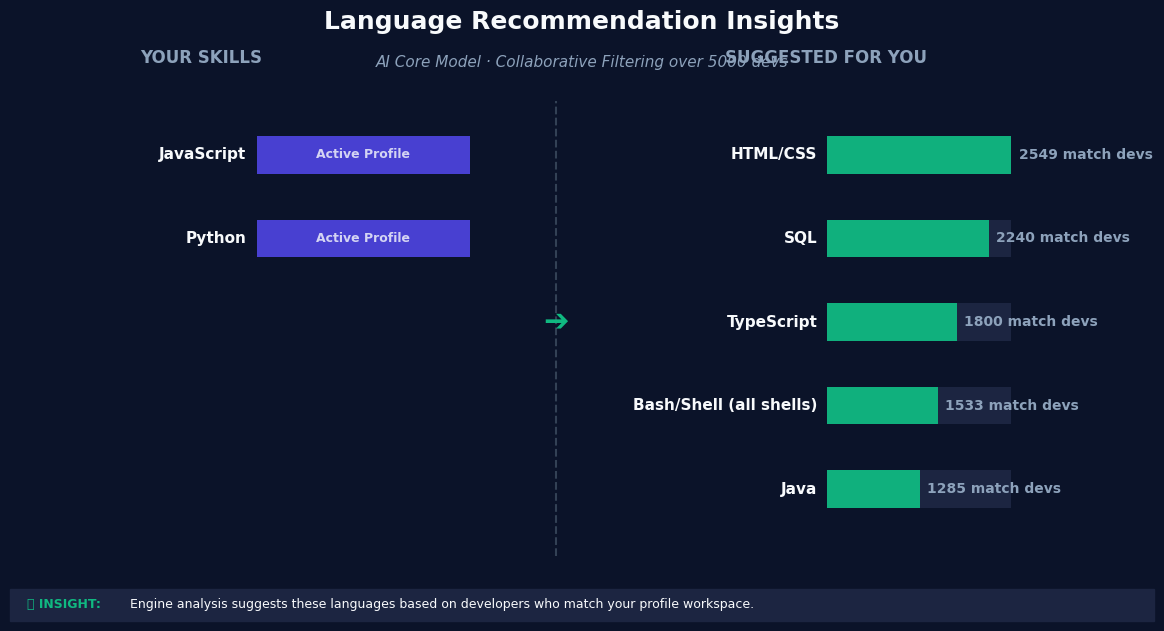

In [ ]:
# meter o user vector o user atual da aplicação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import base64
import requests
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer

# ─────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────
df = pd.read_csv("../DATASET/dataset_expandido.csv")

# ─────────────────────────────────────────────
# PRÉ-PROCESSAMENTO
# ─────────────────────────────────────────────
df_rec = df[["ResponseId", "LanguageHaveWorkedWith"]].copy()
df_rec = df_rec[df_rec["LanguageHaveWorkedWith"] != "Sem dado"]
df_rec = df_rec[df_rec["LanguageHaveWorkedWith"].notna()]
df_rec = df_rec.sample(5000, random_state=42).reset_index(drop=True)

df_rec["Languages"] = df_rec["LanguageHaveWorkedWith"].str.split(";")
df_rec["Languages"] = df_rec["Languages"].apply(
    lambda x: [l.strip() for l in x if l.strip() and l.strip() != "Sem dado"]
)

mlb         = MultiLabelBinarizer()
lang_matrix = mlb.fit_transform(df_rec["Languages"])
lang_df     = pd.DataFrame(lang_matrix,
                            columns=mlb.classes_,
                            index=df_rec["ResponseId"].values)

print(f"Matriz utilizador-linguagem: {lang_df.shape}")
print(f"Total de linguagens: {len(mlb.classes_)}")
print(f"Top 10 linguagens:\n{lang_df.sum().sort_values(ascending=False).head(10)}")

# ─────────────────────────────────────────────
# ESCOLHER UTILIZADOR COM POUCAS LINGUAGENS
# ─────────────────────────────────────────────
lang_counts     = lang_df.sum(axis=1)
usuarios_poucos = lang_counts[(lang_counts >= 2) & (lang_counts <= 4)].index
user_exemplo    = lang_df.index.get_loc(usuarios_poucos[0])

# ─────────────────────────────────────────────
# SISTEMA DE RECOMENDAÇÃO (Para a Avaliação)
# ─────────────────────────────────────────────
def recomendar_linguagens(user_idx, lang_df, n_similar=10, n_recommendations=5):
    user_langs    = lang_df.iloc[user_idx]
    langs_atuais  = set(user_langs[user_langs == 1].index)
    user_vector   = lang_df.iloc[user_idx].values.reshape(1, -1)
    similaridades = cosine_similarity(user_vector, lang_df.values)[0]
    similar_idx   = np.argsort(similaridades)[::-1][1:n_similar+1]
    lang_scores   = lang_df.iloc[similar_idx].sum()
    lang_scores   = lang_scores.drop(
        labels=[l for l in langs_atuais if l in lang_scores.index],
        errors='ignore'
    )
    lang_scores   = lang_scores[lang_scores > 0]
    recomendacoes = lang_scores.sort_values(ascending=False).head(n_recommendations)
    return langs_atuais, recomendacoes

# ─────────────────────────────────────────────
# AVALIAÇÃO — HIT RATE
# ─────────────────────────────────────────────
def avaliar_sistema(lang_df, n_test=50, n_similar=10, n_recommendations=5):
    hits  = 0
    total = 0
    test_idx = np.random.choice(len(lang_df), size=n_test, replace=False)

    for idx in test_idx:
        user_langs   = lang_df.iloc[idx]
        langs_usadas = list(user_langs[user_langs == 1].index)
        if len(langs_usadas) < 2:
            continue
        lang_escondida = np.random.choice(langs_usadas)
        lang_df_temp   = lang_df.copy()

        col_idx = lang_df_temp.columns.get_loc(lang_escondida)
        lang_df_temp.iloc[idx, col_idx] = 0

        _, recomendacoes_test = recomendar_linguagens(
            idx, lang_df_temp, n_similar, n_recommendations)
        if lang_escondida in recomendacoes_test.index:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0

print("A calcular Hit Rate...")
hit_rate = avaliar_sistema(lang_df, n_test=50)
print(f"Hit Rate : {hit_rate:.2%}")

# ─────────────────────────────────────────────
# GERAR O GRÁFICO E ENVIAR TUDO VIA API
# ─────────────────────────────────────────────
def calcular_e_enviar_dashboard(linguagens_do_user, lang_df, mlb, n_similar=20, n_recommendations=5):
    # 1. Algoritmo
    user_matrix  = mlb.transform([linguagens_do_user])
    user_vector  = user_matrix[0].reshape(1, -1)
    langs_atuais = set(linguagens_do_user)

    similaridades = cosine_similarity(user_vector, lang_df.values)[0]
    similar_idx   = np.argsort(similaridades)[::-1]
    similar_idx   = [idx for idx in similar_idx if lang_df.index[idx] != "user_atual"][:n_similar]

    lang_scores = lang_df.iloc[similar_idx].sum()
    lang_scores = lang_scores.drop(labels=[l for l in langs_atuais if l in lang_scores.index], errors='ignore')

    if lang_scores.sum() == 0 or lang_scores.head(n_recommendations).index.tolist() == sorted(lang_scores.head(n_recommendations).index.tolist()):
        linhas_com_intersecao = lang_df[lang_df[list(langs_atuais)].sum(axis=1) > 0]
        if not linhas_com_intersecao.empty:
            lang_scores = linhas_com_intersecao.sum()
            lang_scores = lang_scores.drop(labels=[l for l in langs_atuais if l in lang_scores.index], errors='ignore')

    top_recs_series = lang_scores.sort_values(ascending=False).head(n_recommendations)
    top_recs_list   = top_recs_series.index.tolist()

    # 2. Gráfico Matplotlib
    bg_color   = "#0b1329"
    card_color = "#1c2541"
    text_light = "#f8fafc"
    text_muted = "#8da2bb"
    text_gray  = "#8da2bb"
    color_curr = "#4f46e5"
    color_rec  = "#10b981"

    plt.clf()
    fig = plt.figure(figsize=(13, 6.5), facecolor=bg_color)

    fig.text(0.5, 0.96, "Language Recommendation Insights", ha="center", va="top", fontsize=18, fontweight="bold", color=text_light)
    fig.text(0.5, 0.89, f"AI Core Model · Collaborative Filtering over {len(lang_df)} devs", ha="center", va="top", fontsize=11, color=text_muted, style="italic")

    ax1 = fig.add_axes([0.16, 0.12, 0.27, 0.72])
    ax1.set_facecolor(bg_color)

    langs_list = sorted(langs_atuais)
    y_pos      = range(len(langs_list))

    ax1.barh(y_pos, [100]*len(langs_list), color=color_curr, alpha=0.9, edgecolor="none", height=0.45)

    for i, lang in enumerate(langs_list):
        ax1.text(-5, i, lang, ha="right", va="center", fontsize=11, fontweight="600", color=text_light)
        ax1.text(50, i, "Active Profile", ha="center", va="center", fontsize=9, color=text_light, fontweight="bold", alpha=0.8)

    ax1.set_xlim(-55, 110)
    ax1.set_ylim(-0.8, max(len(langs_list) - 0.2, 4.8))
    ax1.axis("off")
    ax1.set_title("YOUR SKILLS", fontsize=12, fontweight="800", color=text_muted, pad=18, loc="left")
    ax1.invert_yaxis()

    fig.add_artist(plt.Line2D([0.48, 0.48], [0.12, 0.82], color="#334155", linewidth=1.5, linestyle="--", transform=fig.transFigure))
    fig.text(0.48, 0.48, "➔", ha="center", va="center", fontsize=22, color=color_rec, fontweight="bold", transform=fig.transFigure)

    ax2 = fig.add_axes([0.61, 0.12, 0.27, 0.72])
    ax2.set_facecolor(bg_color)

    rec_langs  = list(top_recs_series.index)
    rec_scores = list(top_recs_series.values)
    max_score  = max(rec_scores) if rec_scores else 1

    if rec_langs and max_score > 0:
        for i, (lang, score) in enumerate(zip(rec_langs, rec_scores)):
            pct = score / max_score
            ax2.barh(i, 100, color=card_color, height=0.45, edgecolor="none")
            ax2.barh(i, pct * 100, color=color_rec, alpha=0.95, height=0.45, edgecolor="none")
            ax2.text(-5, i, lang, ha="right", va="center", fontsize=11, fontweight="600", color=text_light)
            ax2.text(pct * 100 + 4, i, f"{score:.0f} match devs", ha="left", va="center", fontsize=10, color=text_gray, fontweight="600")
        ax2.set_ylim(-0.8, 4.8)
        ax2.invert_yaxis()
    else:
        ax2.text(0.5, 0.5, "A processar novos perfis...", ha="center", va="center", fontsize=12, color=text_muted, style="italic")

    ax2.set_xlim(-55, 135)
    ax2.axis("off")
    ax2.set_title("SUGGESTED FOR YOU", fontsize=12, fontweight="800", color=text_muted, pad=18, loc="left")

    insight_ax = fig.add_axes([0.06, 0.02, 0.88, 0.05])
    insight_ax.set_facecolor(card_color)
    insight_ax.set_xlim(0, 1)
    insight_ax.set_ylim(0, 1)
    insight_ax.axis("off")

    rect = mpatches.Rectangle((0, 0), 1, 1, color=card_color, transform=insight_ax.transAxes, clip_on=False)
    insight_ax.add_patch(rect)

    insight_ax.text(0.015, 0.5, "💡 INSIGHT:", fontsize=9, fontweight="900", color=color_rec, va="center")
    insight_ax.text(0.105, 0.5, "Engine analysis suggests these languages based on developers who match your profile workspace.", fontsize=9, color=text_light, va="center")

    # Guardar PNG e converter para HTML via base64
    plt.savefig("recommendation_system.png", dpi=150, bbox_inches="tight", facecolor=bg_color)
    plt.show()
    plt.close()

    with open("recommendation_system.png", "rb") as f:
        img_base64 = base64.b64encode(f.read()).decode("utf-8")

    with open("../Public/assets/recommendation_system.html", "w") as f:
        f.write(f'<img src="data:image/png;base64,{img_base64}" style="max-width:100%; border-radius:12px;">')

    # Enviar recomendações para a API
    url_do_servidor = "http://localhost:3000/developer/api/update-recommendations"
    try:
        requests.post(url_do_servidor, json={"recommendations": top_recs_list})
        print(f"🔥 Sucesso! Gráfico gerado para {linguagens_do_user}.")
    except:
        pass

# --- CORRER O PROCESSO ---
linguagens_do_dashboard = ['Python', 'JavaScript']
calcular_e_enviar_dashboard(linguagens_do_dashboard, lang_df, mlb)